<a href="https://colab.research.google.com/github/beyzahiz/Cats-Dogs-CNN-Classifier/blob/main/Cats_Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/cats_dogs_dataset"

train_dir = DATA_PATH + "/training_set"
test_dir = DATA_PATH + "/test_set"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
#tf.keras.utils.get_file() internetten dosya indirir

def get_datasets(data_dir):
    train_ds = tf.keras.utils.image_dataset_from_directory( #görselleri yükler, label atar, batch oluşturur
        data_dir,
        validation_split= 0.2,
        subset="training",
        seed=42,
        image_size=(150,150),
        batch_size=32
    )

    val_ds=tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=(150,150),
        batch_size=32
    )

    return train_ds, val_ds

In [ ]:
#Data Augmentation
#Eldeki verileri hafifçe değiştirerek daha fazla veri varmış gibi çeşitlilik oluşturmak
#Data augmentation sadece training dataset’te olmalı.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"), #görseli yatayda rastgele çevirir
    layers.RandomRotation(0.1), #%10 oranında döndürür
    layers.RandomZoom(0.1), #Hafif yakınlaştırma
])


In [ ]:
IMG_SIZE=(150,150)

model=keras.Sequential([
    layers.Input(shape=(150,150,3)),
    data_augmentation,
    layers.Rescaling(1./255), #normalizasyon

    #Conv
    #resmin üzerindeki featuresları yakalamaya yarar. resmin içindeki kenarları, köşeleri ve desenleri bulur.
    layers.Conv2D(32, (3,3), activation="relu"), #32 filtre sayısı, 3,3 kernel sayısı
    layers.MaxPooling2D(2,2), #resmi özetler, boyutu küçülür ama en önemli özellikler (mesela kedinin kulağının sivri ucu) korunur.

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"), #128 nöronla karmaşık kuralları öğrenir
    layers.Dropout(0.5), #modelin ezberlemesini engeller, sadece belirli nöronlara güvenmek yerine bilgiyi tüm ağa yaymayı öğrenir.
    layers.Dense(1, activation="sigmoid") #1 çıktı üretilir ve olasılığa dönüşür
])

In [ ]:
model.summary()




Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_10 (Rescaling)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#binary_crossentropy uygulayacağım çünkü 2 sınıf var çıktı 1 tane sigmoid kullanıyorum
#categorical_crossentropy +3 sınıf varsa softmax kullanılıyorsa

train_ds, val_ds = get_datasets(train_dir)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#Early Stopping
#model eğitimi aşamasında kullanılan callback fonksiyonu. overfitting önler
early_stop=keras.callbacks.EarlyStopping(
    monitor="val_loss", #modelin hangi değeri takip edeceği
    patience=5, #eğer val_loss değeri 5 epoch boyunca iyileşmezse eğitimi durdurur.
    restore_best_weights=True #eğitimi durdurduğunda, modelin en iyi performansı gösterdiği (hatanın en düşük olduğu) ana geri döner
)

history= model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.
Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 63s 286ms/step - accuracy: 0.5170 - loss: 0.7555 - val_accuracy: 0.5946 - val_loss: 0.6778
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.6057 - loss: 0.6710 - val_accuracy: 0.6452 - val_loss: 0.6502
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 140ms/step - accuracy: 0.6379 - loss: 0.6452 - val_accuracy: 0.6533 - val_loss: 0.6263
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.6685 - loss: 0.6135 - val_accuracy: 0.7239 - val_loss: 0.5596
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.6883 - loss: 0.5778 - val_accuracy: 0.6839 - val_loss: 0.6071
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.6927 - loss: 0.5811 - val_accuracy: 0.7552 - val_loss: 0.5250
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 141ms/step - accuracy: 0

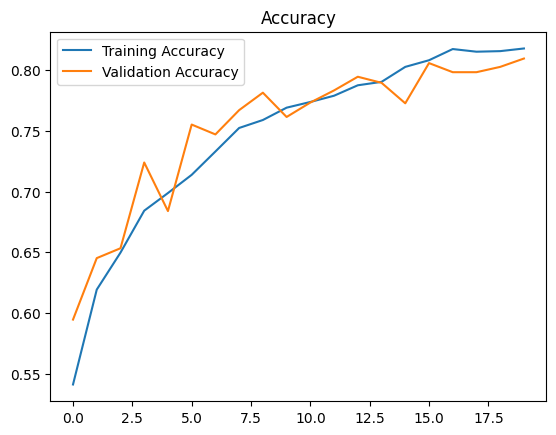

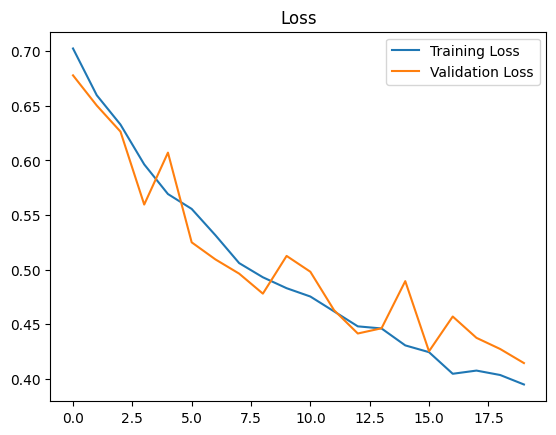

In [ ]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure()
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.figure()
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()

In [ ]:
#GlobalAveragePooling
#Tüm bir haritayı (kanalı) tek bir sayıya dönüştürür. Her channel için ortalama alır. Parametre düşer.

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_11 (Rescaling)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 138ms/step - accuracy: 0.5289 - loss: 0.6908 - val_accuracy: 0.5328 - val_loss: 0.6807
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - accuracy: 0.5744 - loss: 0.6736 - val_accuracy: 0.5322 - val_loss: 0.6800
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.5957 - loss: 0.6548 - val_accuracy: 0.6196 - val_loss: 0.6435
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.5906 - loss: 0.6595 - val_accuracy: 0.6465 - val_loss: 0.6396
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.6111 - loss: 0.6558 - val_accuracy: 0.5715 - val_loss: 0.6614
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.6520 - loss: 0.6324 - val_accuracy: 0.6527 - val_loss: 0.6198
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.6709 - loss: 0.6164 - val_accuracy: 0.6708 - val_loss: 0.6151
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 40s 137ms/step - accuracy: 0.6405 - loss: 0

In [ ]:
#Batch Normalization
#Ağ içindeki her bir "batch" (grup) veri için şu matematiksel işlemi yapar: Verinin ortalamasını alır.
#Verinin standart sapmasını (dağılımını) hesaplar. Verileri bu değerleri kullanarak normalize eder (genellikle ortalaması 0, standart sapması 1 olacak şekilde).

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])



In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 142ms/step - accuracy: 0.5643 - loss: 0.7700 - val_accuracy: 0.4922 - val_loss: 0.8037
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.6038 - loss: 0.6918 - val_accuracy: 0.5921 - val_loss: 0.6720
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.6162 - loss: 0.6649 - val_accuracy: 0.5397 - val_loss: 0.7939
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 140ms/step - accuracy: 0.6611 - loss: 0.6265 - val_accuracy: 0.6677 - val_loss: 0.6188
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.6584 - loss: 0.6186 - val_accuracy: 0.5940 - val_loss: 0.7408
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.6749 - loss: 0.5932 - val_accuracy: 0.5259 - val_loss: 1.3384
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 40s 143ms/step - accuracy: 0.6894 - loss: 0.5911 - val_accuracy: 0.5334 - val_loss: 1.2402
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.7045 - loss: 0

In [ ]:
#ReduceLROnPlateau
#model eğitimi sırasında öğrenmenin durakladığı anları fark eder ve öğrenme oranını otomatik olarak düşürür

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5, # Yeni LR = Eski LR * factor, öğrenme oranını 5 kat düşürür
    patience=2,
    min_lr=1e-6, #Öğrenme oranının düşebileceği en alt sınır
    verbose=1
)

history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.7332 - loss: 0.5308 - val_accuracy: 0.6777 - val_loss: 0.6682 - learning_rate: 0.0010
Epoch 2/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 144ms/step - accuracy: 0.7427 - loss: 0.5244 - val_accuracy: 0.6958 - val_loss: 0.5830 - learning_rate: 0.0010
Epoch 3/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.7505 - loss: 0.5123 - val_accuracy: 0.7077 - val_loss: 0.6158 - learning_rate: 0.0010
Epoch 4/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 143ms/step - accuracy: 0.7483 - loss: 0.5077 - val_accuracy: 0.7277 - val_loss: 0.5673 - learning_rate: 0.0010
Epoch 5/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.7502 - loss: 0.5148 - val_accuracy: 0.7433 - val_loss: 0.4998 - learning_rate: 0.0010
Epoch 6/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.7532 - loss: 0.5026 - val_accuracy: 0.7508 - val_loss: 0.5249 - learning_rate: 0.0010
Epoch 7/25
200/201 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.75

In [ ]:
#DropOut
model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 32s 144ms/step - accuracy: 0.5755 - loss: 0.7260 - val_accuracy: 0.4916 - val_loss: 0.9210
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6156 - loss: 0.6666 - val_accuracy: 0.6221 - val_loss: 0.6453
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.6373 - loss: 0.6420 - val_accuracy: 0.5821 - val_loss: 0.7014
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6720 - loss: 0.6077 - val_accuracy: 0.6234 - val_loss: 0.6883
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6677 - loss: 0.6077 - val_accuracy: 0.5890 - val_loss: 0.8251
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.6860 - loss: 0.5940 - val_accuracy: 0.5178 - val_loss: 1.5693
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 143ms/step - accuracy: 0.7067 - loss: 0.5745 - val_accuracy: 0.6696 - val_loss: 0.6217
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 42s 146ms/step - accuracy: 0.6929 - loss: 0

In [ ]:
#Learning Rate Tuning

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 32s 146ms/step - accuracy: 0.5743 - loss: 0.7595 - val_accuracy: 0.4909 - val_loss: 0.7884
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.6056 - loss: 0.6983 - val_accuracy: 0.5415 - val_loss: 0.6923
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step - accuracy: 0.6140 - loss: 0.6763 - val_accuracy: 0.5665 - val_loss: 0.6845
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.6366 - loss: 0.6373 - val_accuracy: 0.6321 - val_loss: 0.6282
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 143ms/step - accuracy: 0.6740 - loss: 0.6109 - val_accuracy: 0.6646 - val_loss: 0.6192
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - accuracy: 0.6811 - loss: 0.5975 - val_accuracy: 0.6846 - val_loss: 0.6110
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.6757 - loss: 0.6035 - val_accuracy: 0.6883 - val_loss: 0.5738
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6883 - loss: 0

In [ ]:
#son deneme

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 32s 143ms/step - accuracy: 0.5451 - loss: 0.7509 - val_accuracy: 0.4916 - val_loss: 0.8175
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.5893 - loss: 0.7011 - val_accuracy: 0.4916 - val_loss: 1.0024
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.5869 - loss: 0.7019 - val_accuracy: 0.5921 - val_loss: 0.6820
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.6140 - loss: 0.6783 - val_accuracy: 0.6021 - val_loss: 0.6972
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6124 - loss: 0.6765 - val_accuracy: 0.6396 - val_loss: 0.6278
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6147 - loss: 0.6764 - val_accuracy: 0.6471 - val_loss: 0.6189
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.6291 - loss: 0.6555 - val_accuracy: 0.6309 - val_loss: 0.6436
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6290 - loss: 0

- BatchNorm neden ReLU’dan önce?
BatchNorm ne yapıyor?
Çıktının ortalamasını 0’a yaklaştırır. Standart sapmasını 1’e yaklaştırır. Aktivasyonları stabilize eder

Eğer ReLU’dan sonra BN olursa:
ReLU negatifleri sıfırlar → dağılım bozulur. Sonra BN tekrar normalize etmeye çalışır. Bu stabil değildir.

BN, aktivasyondan önce dağılımı düzenler. Sonra ReLU temiz, dengeli veri alır.
Bu yüzden doğru sıralama: Conv → BN → ReLU

- Dropout neden BN’den sonra?
BatchNorm istatistik hesaplar: Ortalama, Varyans

Dropout önce olursa: Rastgele nöronlar kapanır. Dağılım her batch’te değişir. BN'nin hesapladığı istatistikler tutarsız olur. Bu modelin öğrenmesini zorlaştırır.

Doğru sıra: Conv → BN → ReLU → Dropout


In [ ]:
#ReduceLROnPlateau en iyi sonucu veren

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop, reduce_lr]
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(150,150),
    batch_size=32
)

model.evaluate(test_ds)


Epoch 1/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6377 - loss: 0.6526 - val_accuracy: 0.6540 - val_loss: 0.6277 - learning_rate: 1.0000e-04
Epoch 2/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.6229 - loss: 0.6633 - val_accuracy: 0.6096 - val_loss: 0.6650 - learning_rate: 1.0000e-04
Epoch 3/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.6425 - loss: 0.6451 - val_accuracy: 0.6652 - val_loss: 0.6037 - learning_rate: 1.0000e-04
Epoch 4/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.6554 - loss: 0.6466 - val_accuracy: 0.6452 - val_loss: 0.6273 - learning_rate: 1.0000e-04
Epoch 5/25
200/201 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6554 - loss: 0.6305
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.6553 - loss: 0.6306 - val_accuracy: 0.6309 - val_loss: 0.6882 - learning_rate: 1.0000e-04
Epoch 6/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/st

[0.5812934637069702, 0.6920415163040161]

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.flatten())

cm = confusion_matrix(y_true, y_pred)
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━